# FCS Cy5

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.figure as fi

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [16]:
fluorophores = fl.construct_fluorophores('cy5', 10, 3)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, 2.5, 640)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=['HFRET', 'OFRET', 'TFRET', 'CFRET', 'RED', 'OXI'])
transition_set.finalize()
prediction = st.Prediction(transition_set)
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='5ms', emccd_gain=1, seed=100)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-13, exp_max=-4)
antibunching = fc.fit_antibunching(tau=fcs.tau, excitation_rate=transition_set.transition_df.at[0, 'rate'], s1_lifetime=1e-9)
triplet_cis, norm = fc.fit_triplet_cis(tau=fcs.tau, k_isc=8.3e5, k_T=5e5, k_01=7.27e6, 
                                       k_10=1e9, k_iso=2e7, k_biso_eff=1.37e5)

In [17]:
number_fluorophores = 3
fit_combined = (antibunching + triplet_cis) / (norm * number_fluorophores) + 1

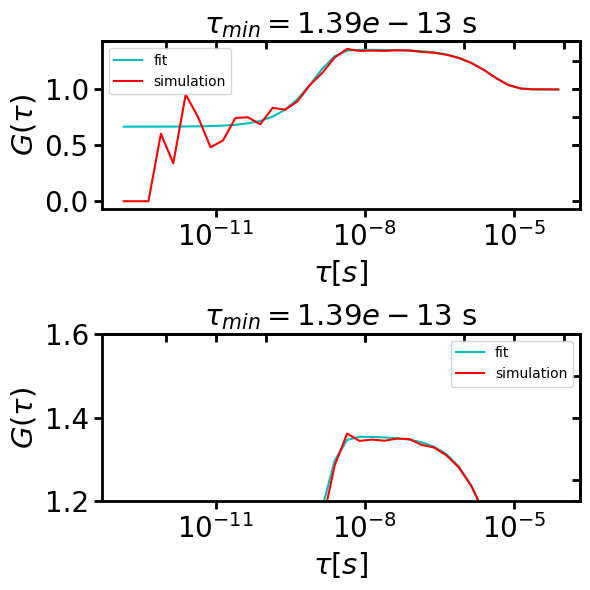

In [18]:
axes = fi.universal_figure(data=[fcs.tau, fit_combined], color='c', label='fit',
                           nrows=2, fig_height=6)
_ = fcs.plot(axes=axes[0, 0], color='r', label='simulation', legend=True)
_ = fi.universal_figure(data=[fcs.tau, fit_combined], color='c', label='fit',
                        axes=axes[1, 0])
_ = fcs.plot(axes=axes[1, 0], color='r', label='simulation', legend=True, ylim=[1.2, 1.6])
axes[0, 0].get_figure().tight_layout()

In [2]:
fluorophores = fl.construct_fluorophores('cy5', 10, 2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, 2.5, 640)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=['HFRET', 'OFRET', 'TFRET', 'CFRET', 'RED', 'OXI'])
transition_set.finalize()
prediction = st.Prediction(transition_set)
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='5ms', emccd_gain=1, seed=100)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-13, exp_max=-4)
antibunching = fc.fit_antibunching(tau=fcs.tau, excitation_rate=transition_set.transition_df.at[0, 'rate'], s1_lifetime=1e-9)
triplet_cis, norm = fc.fit_triplet_cis(tau=fcs.tau, k_isc=8.3e5, k_T=5e5, k_01=7.27e6, 
                                       k_10=1e9, k_iso=2e7, k_biso_eff=1.37e5)

In [3]:
number_fluorophores = 2
fit_combined = (antibunching + triplet_cis) / (norm * number_fluorophores) + 1

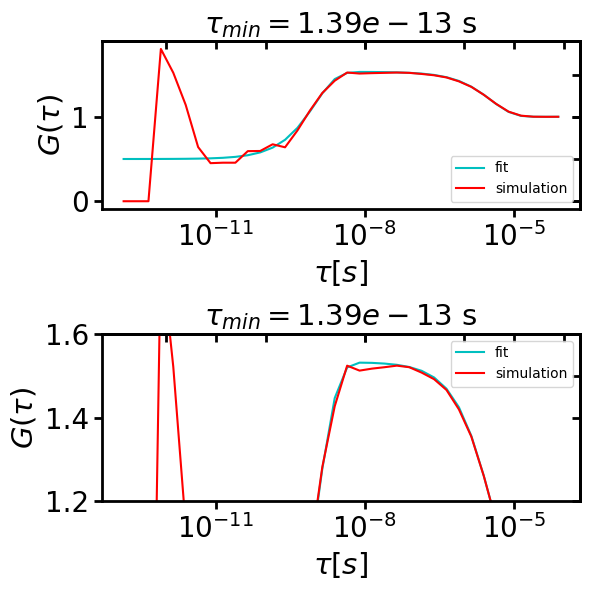

In [22]:
axes = fi.universal_figure(data=[fcs.tau, fit_combined], color='c', label='fit',
                           nrows=2, fig_height=6)
_ = fcs.plot(axes=axes[0, 0], color='r', label='simulation', legend=True)
_ = fi.universal_figure(data=[fcs.tau, fit_combined], color='c', label='fit',
                        axes=axes[1, 0])
_ = fcs.plot(axes=axes[1, 0], color='r', label='simulation', legend=True, ylim=[1.2, 1.6])
axes[0, 0].get_figure().tight_layout()

In [23]:
fluorophores = fl.construct_fluorophores('cy5', 10, 4)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, 2.5, 640)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=['HFRET', 'OFRET', 'TFRET', 'CFRET', 'RED', 'OXI'])
transition_set.finalize()
prediction = st.Prediction(transition_set)
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='5ms', emccd_gain=1, seed=100)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-13, exp_max=-4)
antibunching = fc.fit_antibunching(tau=fcs.tau, excitation_rate=transition_set.transition_df.at[0, 'rate'], s1_lifetime=1e-9)
triplet_cis, norm = fc.fit_triplet_cis(tau=fcs.tau, k_isc=8.3e5, k_T=5e5, k_01=7.27e6, 
                                  k_10=1e9, k_iso=2e7, k_biso_eff=1.37e5)

In [24]:
number_fluorophores = 4
fit_combined = (antibunching + triplet_cis) / (norm * number_fluorophores) + 1

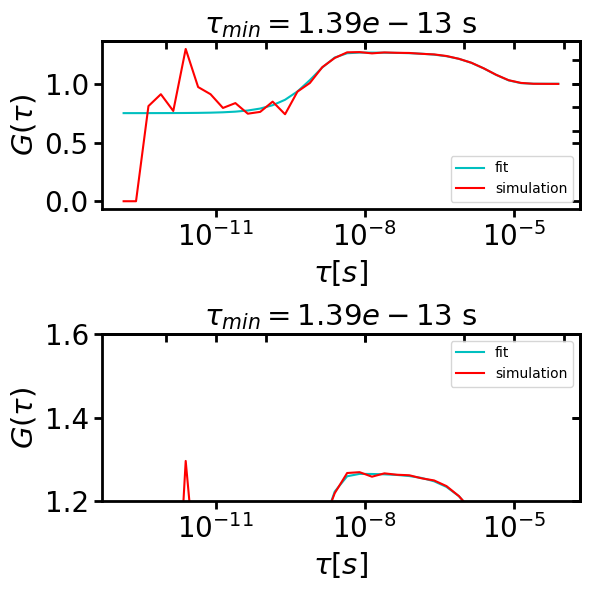

In [25]:
axes = fi.universal_figure(data=[fcs.tau, fit_combined], color='c', label='fit',
                           nrows=2, fig_height=6)
_ = fcs.plot(axes=axes[0, 0], color='r', label='simulation', legend=True)
_ = fi.universal_figure(data=[fcs.tau, fit_combined], color='c', label='fit',
                        axes=axes[1, 0])
_ = fcs.plot(axes=axes[1, 0], color='r', label='simulation', legend=True, ylim=[1.2, 1.6])
axes[0, 0].get_figure().tight_layout()